# Actividad 4.x — Detección de Señales de Tránsito con CNN (GTSRB)
### MR4010.10 Navegación Autónoma — Maestría en Inteligencia Artificial (Tec de Monterrey)

**Equipo:** Antonio Olvera Donlucas (A01795617) · Carlos Monir Radovich Saad (A01797569) · Andrés Roberto Osuna González (A01796264) · Oscar Alberto Ramírez Anaya (A01795438)

**Objetivo:** diseñar, entrenar y evaluar una Red Neuronal Convolucional (CNN) en Keras para clasificar las **43 clases** del dataset **GTSRB**, superando **90%** de exactitud, y exportar el modelo a **TensorFlow Lite** para integrarlo en un controlador de Webots.

> **Declaración de uso de IA:** Se utilizó *Claude (Anthropic)* como asistente para la generación y depuración de código. La responsabilidad final del contenido recae en el equipo. La etapa de *fine-tuning de dominio* (sección 7) es una técnica de adaptación declarada explícitamente.

## 1. Configuración y GPU
Activa la GPU en Colab: **Entorno de ejecución → Cambiar tipo de entorno → GPU**.

In [1]:
import tensorflow as tf
import numpy as np, pandas as pd, cv2, os
import matplotlib.pyplot as plt
try:
    import seaborn as sns; HAS_SNS = True
except ImportError:
    HAS_SNS = False
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE, NUM_CLASSES, SEED = 32, 43, 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TensorFlow 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Descarga del dataset GTSRB (Kaggle)
El dataset está en Kaggle: `meowmeowmeowmeowmeow/gtsrb-german-traffic-sign`.
Sube tu archivo `kaggle.json` (Cuenta de Kaggle → Settings → Create New API Token) cuando se solicite.

In [3]:
  # --- Descarga GTSRB con token KGAT (nuevo formato de Kaggle) ---
  import os
  import getpass
  os.environ['KAGGLE_API_TOKEN'] = getpass.getpass('Pega tu token KGAT de Kaggle: ')  # se pide al ejecutar; NO se guarda en git

  !pip -q install --upgrade kaggle
  !kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
  !unzip -q -o gtsrb-german-traffic-sign.zip -d GTSRB

  DATA_DIR = 'GTSRB'
  print('Contenido:', os.listdir(DATA_DIR))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 10.8 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:07<00:00, 83.0MB/s]

Contenido: ['Test.csv', 'train', 'Test', 'Meta.csv', 'Train', 'meta', 'Meta', 'test', 'Train.csv']


## 3. Carga y preprocesamiento
Cada imagen se convierte a **RGB**, se redimensiona a **32×32** y se normaliza a **[0,1]**.
- Entrenamiento: subcarpetas `Train/0 .. Train/42` (una por clase).
- Prueba: `Test.csv` con las columnas `ClassId` y `Path` (conjunto oficial).

In [4]:
def cargar_entrenamiento(data_dir):
    train_dir = os.path.join(data_dir, 'Train'); X, y = [], []
    for cid in range(NUM_CLASSES):
        cdir = os.path.join(train_dir, str(cid))
        if not os.path.isdir(cdir): continue
        for fn in os.listdir(cdir):
            if not fn.lower().endswith(('.png','.ppm','.jpg','.jpeg')): continue
            img = cv2.imread(os.path.join(cdir, fn))
            if img is None: continue
            img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
            X.append(img); y.append(cid)
    return np.array(X, np.float32)/255.0, np.array(y, np.int64)

def cargar_prueba(data_dir):
    csv = os.path.join(data_dir, 'Test.csv')
    if not os.path.exists(csv): return None, None
    df = pd.read_csv(csv); X, y = [], []
    for _, r in df.iterrows():
        img = cv2.imread(os.path.join(data_dir, r['Path']))
        if img is None: continue
        img = cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), (IMG_SIZE, IMG_SIZE))
        X.append(img); y.append(int(r['ClassId']))
    return np.array(X, np.float32)/255.0, np.array(y, np.int64)

X, y = cargar_entrenamiento(DATA_DIR)
X_test, y_test = cargar_prueba(DATA_DIR)
print('Entrenamiento:', X.shape, '| Prueba:', None if X_test is None else X_test.shape)

Entrenamiento: (39209, 32, 32, 3) | Prueba: (12630, 32, 32, 3)


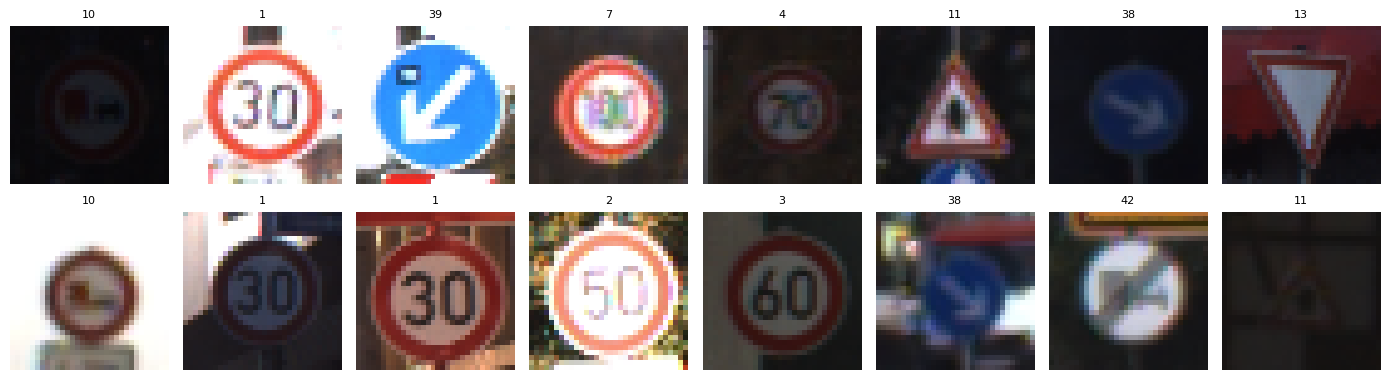

In [5]:
# Vistazo a algunas senales del dataset
fig, ax = plt.subplots(2, 8, figsize=(14, 4))
for a in ax.ravel():
    i = np.random.randint(len(X)); a.imshow(X[i]); a.set_title(int(y[i]), fontsize=8); a.axis('off')
plt.tight_layout(); plt.show()

## 4. Arquitectura de la CNN
Dos bloques convolucionales (32 y 64 filtros) + clasificador denso. Se ejercitan las capas que pide la rúbrica: **Convolution**, **Pooling**, **Dropout** y **Fully-Connected**.

In [6]:
from tensorflow.keras import layers, models

def construir_cnn():
    model = models.Sequential([
        layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu'),
        layers.MaxPooling2D(2),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax'),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

model = construir_cnn(); model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,699 (2.54 MB)

 Trainable params: 666,699 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento
Aumentación de datos (rotación, zoom, desplazamiento) para simular las variaciones de perspectiva de las señales vistas desde el vehículo. **No** se usa flip horizontal (invertiría el significado).

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

idx = np.arange(len(X)); np.random.default_rng(SEED).shuffle(idx)
nval = int(0.2*len(X)); vi, ti = idx[:nval], idx[nval:]
Xtr, ytr, Xval, yval = X[ti], y[ti], X[vi], y[vi]

datagen = ImageDataGenerator(rotation_range=12, zoom_range=0.15,
                             width_shift_range=0.10, height_shift_range=0.10, shear_range=0.10)
datagen.fit(Xtr)
cbs = [EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
       ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)]

history = model.fit(datagen.flow(Xtr, ytr, batch_size=128),
                    validation_data=(Xval, yval), epochs=25, callbacks=cbs, verbose=2)

Epoch 1/25
246/246 - 32s - 129ms/step - accuracy: 0.2458 - loss: 2.7018 - val_accuracy: 0.5694 - val_loss: 1.3597 - learning_rate: 0.0010
Epoch 2/25
246/246 - 19s - 76ms/step - accuracy: 0.5643 - loss: 1.3727 - val_accuracy: 0.8646 - val_loss: 0.4637 - learning_rate: 0.0010
Epoch 3/25
246/246 - 21s - 86ms/step - accuracy: 0.7382 - loss: 0.8145 - val_accuracy: 0.9527 - val_loss: 0.1764 - learning_rate: 0.0010
Epoch 4/25
246/246 - 39s - 158ms/step - accuracy: 0.8295 - loss: 0.5320 - val_accuracy: 0.9788 - val_loss: 0.0925 - learning_rate: 0.0010
Epoch 5/25
246/246 - 18s - 74ms/step - accuracy: 0.8730 - loss: 0.4063 - val_accuracy: 0.9890 - val_loss: 0.0558 - learning_rate: 0.0010
Epoch 6/25
246/246 - 19s - 79ms/step - accuracy: 0.8943 - loss: 0.3355 - val_accuracy: 0.9935 - val_loss: 0.0407 - learning_rate: 0.0010
Epoch 7/25
246/246 - 19s - 78ms/step - accuracy: 0.9161 - loss: 0.2626 - val_accuracy: 0.9927 - val_loss: 0.0285 - learning_rate: 0.0010
Epoch 8/25
246/246 - 20s - 80ms/step - 

## 6. Evaluación
Exactitud en el conjunto de prueba oficial, reporte de clasificación, curvas y matriz de confusión.

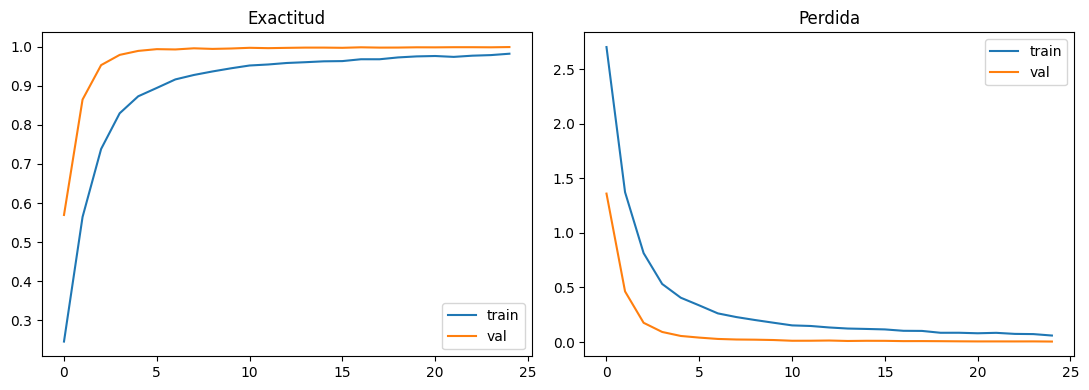

In [8]:
# Curvas de entrenamiento
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(history.history['accuracy'], label='train'); ax[0].plot(history.history['val_accuracy'], label='val')
ax[0].set_title('Exactitud'); ax[0].legend()
ax[1].plot(history.history['loss'], label='train'); ax[1].plot(history.history['val_loss'], label='val')
ax[1].set_title('Perdida'); ax[1].legend()
plt.tight_layout(); plt.savefig('training_curves.png', dpi=120); plt.show()

Exactitud en prueba GTSRB: 98.00%  -> META CUMPLIDA (>90%)
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        60
           1      0.986     1.000     0.993       720
           2      0.989     0.993     0.991       750
           3      0.991     0.987     0.989       450
           4      1.000     0.986     0.993       660
           5      0.984     0.973     0.978       630
           6      1.000     0.967     0.983       150
           7      0.996     0.996     0.996       450
           8      0.987     0.991     0.989       450
           9      0.996     1.000     0.998       480
          10      1.000     0.994     0.997       660
          11      0.957     0.998     0.977       420
          12      0.972     0.965     0.969       690
          13      0.984     0.994     0.989       720
          14      1.000     1.000     1.000       270
          15      0.972     0.995     0.984       210
          16      0.99

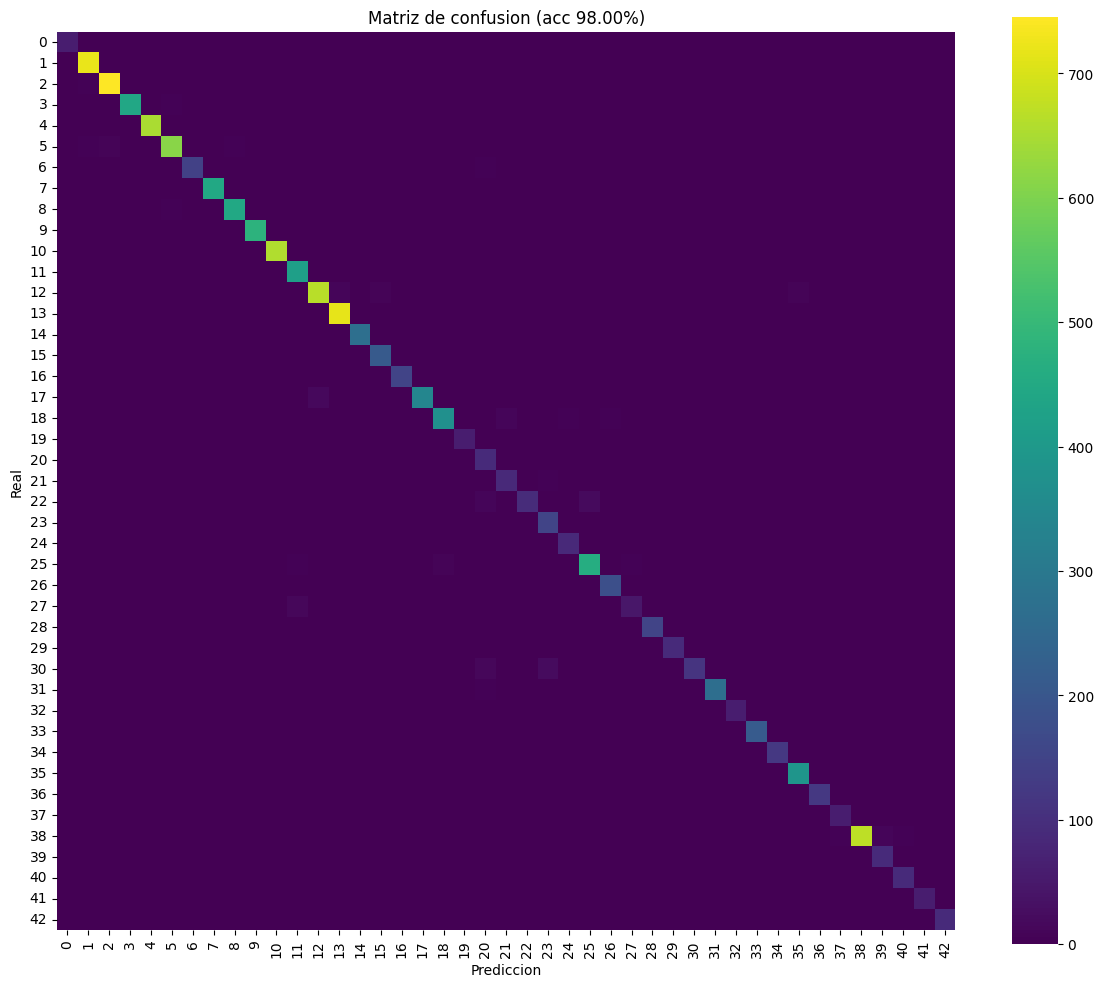

In [9]:
if X_test is not None:
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'Exactitud en prueba GTSRB: {acc*100:.2f}%  ->', 'META CUMPLIDA (>90%)' if acc>0.9 else 'NO cumplida')
    ypred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    print(classification_report(y_test, ypred, digits=3, zero_division=0))
    cm = confusion_matrix(y_test, ypred)
    plt.figure(figsize=(12,10))
    (sns.heatmap(cm, cmap='viridis', square=True) if HAS_SNS else plt.imshow(cm, cmap='viridis'))
    plt.title(f'Matriz de confusion (acc {acc*100:.2f}%)'); plt.xlabel('Prediccion'); plt.ylabel('Real')
    plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=120); plt.show()

## 7. Fine-tuning de dominio (señales reales de Webots)
Las texturas de Webots (estilo EE.UU.) difieren de las señales alemanas de GTSRB. Para que el modelo reconozca las señales **dentro del simulador**, se reajusta con recortes reales capturados en Webots (tecla `A` del controlador), organizados como `webots_signs/<class_id>/*.png`. Técnica declarada: **transfer learning + aumentación**.

Sube un `webots_signs.zip` con esa estructura. Si aún no tienes recortes, **omite esta sección** y entrega el modelo solo-GTSRB (reconocerá ALTO y CEDA EL PASO de forma nativa).

## 8. Exportación a Keras + TensorFlow Lite
El controlador de Webots carga el `.tflite`. Se verifica la **paridad** entre el modelo Keras y el TFLite.

In [11]:
model.save('gtsrb_cnn.keras')
conv = tf.lite.TFLiteConverter.from_keras_model(model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = conv.convert()
open('gtsrb_cnn.tflite','wb').write(tflite_model)
print('TFLite:', len(tflite_model)/1024, 'KB')

# Paridad Keras vs TFLite
if X_test is not None:
    interp = tf.lite.Interpreter(model_content=tflite_model); interp.allocate_tensors()
    ii, oo = interp.get_input_details()[0], interp.get_output_details()[0]
    ms = X_test[:20]; kp = np.argmax(model.predict(ms, verbose=0), axis=1); tp = []
    for i in range(len(ms)):
        interp.set_tensor(ii['index'], ms[i:i+1]); interp.invoke()
        tp.append(int(np.argmax(interp.get_tensor(oo['index'])[0])))
    print('Paridad:', float(np.mean(kp==np.array(tp))*100), '%')

from google.colab import files
files.download('gtsrb_cnn.tflite'); files.download('gtsrb_cnn.keras')

Saved artifact at '/tmp/tmpd6r1i23w'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  133569380701520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380703632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380704016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380704208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380702864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380704784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380702480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380704976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380705744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133569380706704

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Paridad: 100.0 %


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Integración en Webots
1. Copia `gtsrb_cnn.tflite` a `controllers/sign_detector/` (y a `cnn_training/model/`).
2. Instala el runtime de inferencia en el entorno Python de Webots: `pip install ai-edge-litert` (o `pip install tensorflow` como respaldo).
3. Abre `worlds/city_2025b_lidar.wbt`, verifica que el `BmwX5` use el controlador `sign_detector` y presiona **Play**. Conduce con las flechas; la pantalla de a bordo mostrará la señal detectada.